In [1]:
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.25)

In [3]:
import medmnist
from medmnist import INFO, Evaluator

In [19]:
# Import local files
%load_ext autoreload
%autoreload 2
from cnn_training import *
from plots import *
from cnn import *
from constants import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
data_flag = 'dermamnist'
download = True

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

In [6]:
info

{'python_class': 'DermaMNIST',
 'description': 'The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/dermamnist.npz?download=1',
 'MD5': '0744692d530f8e62ec473284d019b0c7',
 'url_64': 'https://zenodo.org/records/10519652/files/dermamnist_64.npz?download=1',
 'MD5_64': 'b70a2f5635c6199aeaa28c31d7202e1f',
 'url_128': 'https://zenodo.org/records/10519652/files/dermamnist_128.npz?download=1',
 'MD5_128': '2defd784463fa5243564e855ed717de1',
 'url_224': 'https://zenodo.org/records/10519652/files/dermamnist_224.npz?download=1',
 'MD5_224': '8974907d8e169bef5f5b96bc506ae45d',
 'task': 'multi-c

In [7]:
# Note: this preprocesses data such that it has mean 0.5 and std dev 0.5.
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# load the data
train_dataset = DataClass(split='train', transform=data_transform, download=download)
val_dataset = DataClass(split='val', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)

BATCH_SIZE = 128

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
# train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

In [8]:
from sklearn.utils.class_weight import compute_class_weight
all_labels = train_dataset.labels.squeeze()
class_weights = compute_class_weight(class_weight='balanced', classes=np.arange(7), y=all_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float32)

def default_setup(lr=0.001, l2_weight=0.0):
    model = CNN(n_channels, n_classes)
    # criterion = nn.CrossEntropyLoss(weight=class_weights)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=l2_weight)
    return model, criterion, optimizer

## Fully Labeled Dataset
What kind of performance can we get if we leave all labels in the dataset?
This might be helpful just to view as an upper bound, like our best possible performance

In [24]:
cnn_labeled, criterion, optimizer = default_setup()
np.random.seed(42)  # reset after get_semi_supervised_labels
torch.manual_seed(42)

train_history = train_loop_labeled(cnn_labeled, train_loader, val_loader, criterion, optimizer, num_epochs=20)

100%|██████████| 55/55 [00:04<00:00, 13.09it/s]


Epoch 1/20 | Train Loss: 0.9478 | Val Loss: 0.8331 | Val AUC Macro: 0.8584 | Val AUC Global: 0.9420


100%|██████████| 55/55 [00:04<00:00, 13.12it/s]


Epoch 2/20 | Train Loss: 0.8039 | Val Loss: 0.7584 | Val AUC Macro: 0.8887 | Val AUC Global: 0.9522


100%|██████████| 55/55 [00:04<00:00, 13.11it/s]


...

Epoch 18/20 | Train Loss: 0.3665 | Val Loss: 0.8399 | Val AUC Macro: 0.9181 | Val AUC Global: 0.9593


100%|██████████| 55/55 [00:04<00:00, 13.05it/s]


Epoch 19/20 | Train Loss: 0.3172 | Val Loss: 0.8321 | Val AUC Macro: 0.9088 | Val AUC Global: 0.9551


100%|██████████| 55/55 [00:04<00:00, 13.05it/s]


Epoch 20/20 | Train Loss: 0.3025 | Val Loss: 0.8504 | Val AUC Macro: 0.9159 | Val AUC Global: 0.9581


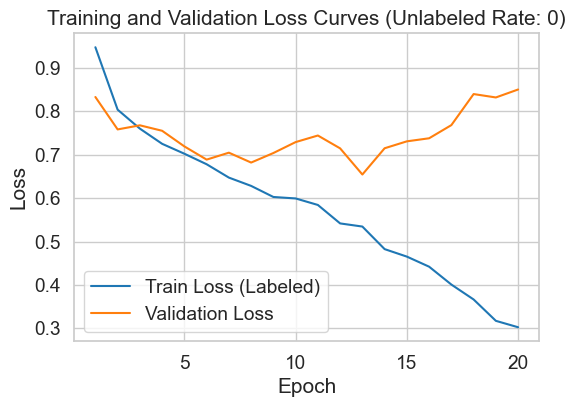

In [25]:
plot_loss_curves(train_history)

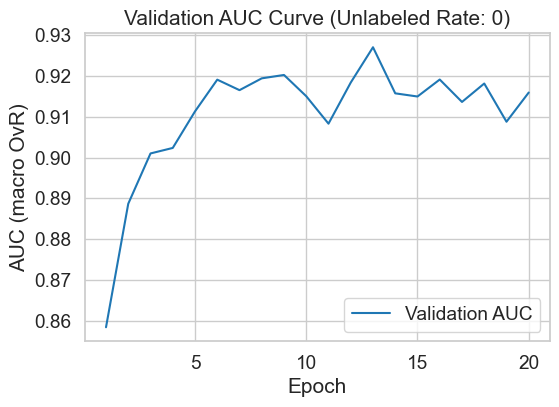

In [26]:
plot_auc_curve(train_history)

In [27]:
best = max(train_history, key=lambda x: x['val_auc_macro'])
print(f"Best Epoch: {best['epoch']} | Val AUC: {best['val_auc_macro']:.4f} | Val Loss: {best['val_loss']:.4f}")

best_model_upper_bound = CNN(n_channels, n_classes)
best_model_upper_bound.load_state_dict(best['model_state'])

Best Epoch: 13 | Val AUC: 0.9270 | Val Loss: 0.6545


<All keys matched successfully>

In [28]:
test_metrics = evaluate(best_model_upper_bound, test_loader)
print(f"Test AUC Macro: {test_metrics['macro_auc']:.4f} | Test AUC Global: {test_metrics['global_auc']:.4f}")
print(f"Test Macro NLL: {test_metrics['macro_nll']:.4f} | Test Per-Class NLL: {test_metrics['per_class_nll']}")

Test AUC Macro: 0.9239 | Test AUC Global: 0.9649
Test Macro NLL: 1.4823 | Test Per-Class NLL: [1.8980656  1.4777851  1.4497406  2.639275   1.5621701  0.20537274
 1.1434988 ]


In [61]:
class_probs = [[] for _ in range(7)]
with torch.no_grad():
    best_model_upper_bound.eval()
    for images, labels in train_loader:
        outputs = best_model_upper_bound(images)
        probs = torch.softmax(outputs, dim=1)
        for i in range(7):
            mask = (labels.squeeze() == i)
            if mask.sum() > 0:
                class_probs[i].append(probs[mask])

for i in range(7):
    if class_probs[i]:
        mean_dist = torch.cat(class_probs[i]).mean(dim=0).numpy()
        print(f"Class {i}: {np.round(mean_dist, 3)}")

Class 0: [0.474 0.235 0.119 0.021 0.106 0.043 0.002]
Class 1: [0.053 0.655 0.069 0.036 0.056 0.073 0.057]
Class 2: [0.027 0.06  0.54  0.008 0.145 0.215 0.005]
Class 3: [0.043 0.275 0.077 0.358 0.039 0.156 0.053]
Class 4: [0.017 0.019 0.081 0.002 0.701 0.177 0.004]
Class 5: [0.003 0.011 0.04  0.002 0.089 0.851 0.005]
Class 6: [0.    0.016 0.01  0.002 0.037 0.085 0.85 ]


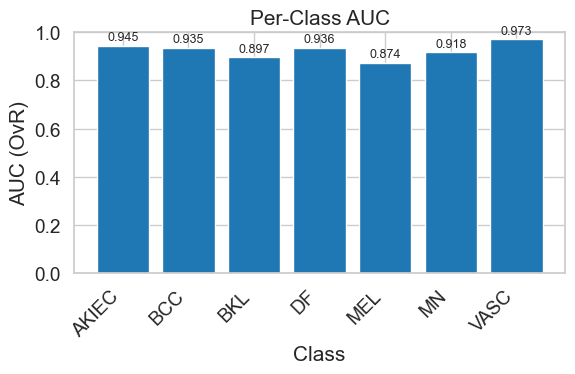

In [37]:
perclass_auc, confusion_matrix = evaluate_perclass(best_model_upper_bound, test_loader)
plot_perclass_auc(perclass_auc, list(short_labels.values()))

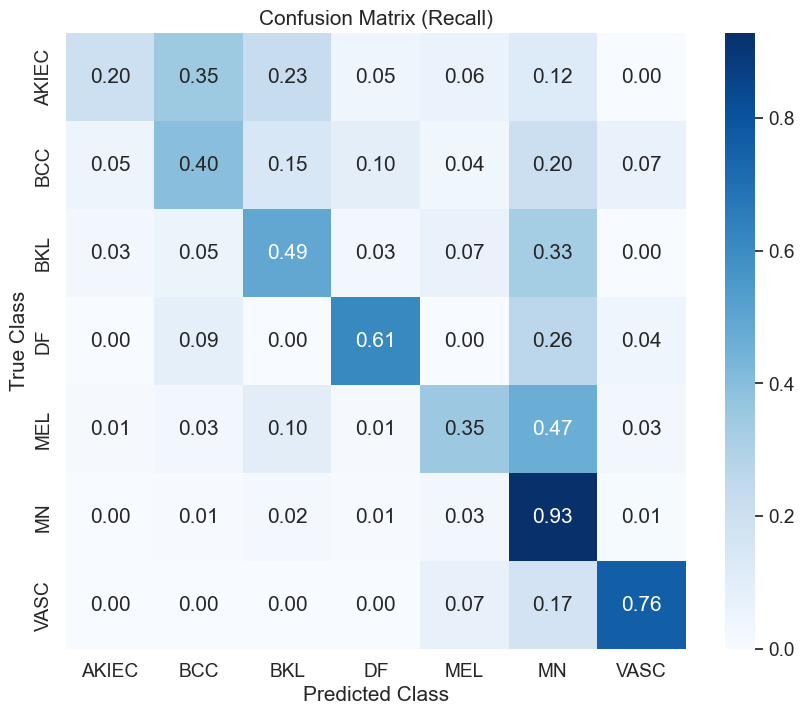

In [38]:
plot_per_class_recall(confusion_matrix, list(short_labels.values()))

## Create SSL versions of the dataset - start with 50% unlabeled rate

In [10]:
RANDOM_SEED = 42

In [26]:
# Create SSL versions of our datasets
unlabeled_rate = 0.5

# print(train_dataset.labels)
# print(train_dataset.imgs)
train_labels_ssl_50 = get_semi_supervised_labels(train_dataset, unlabeled_rate=unlabeled_rate, seed=RANDOM_SEED)
train_ssl_dataset_50 = SSLDataset(train_dataset, train_labels_ssl_50)
train_ssl_loader_50 = data.DataLoader(train_ssl_dataset_50, batch_size=BATCH_SIZE, shuffle=True)

Unlabeled rate: 0.5 | Total examples: 7007 | Labeled examples: 3506 | Unlabeled examples: 3501
Class 0: 114/228 labeled, 114 unlabeled
Class 1: 180/359 labeled, 179 unlabeled
Class 2: 385/769 labeled, 384 unlabeled
Class 3: 40/80 labeled, 40 unlabeled
Class 4: 390/779 labeled, 389 unlabeled
Class 5: 2347/4693 labeled, 2346 unlabeled
Class 6: 50/99 labeled, 49 unlabeled


In [27]:
ssl_model_50, criterion, optimizer = default_setup()
ssl_history_50 = train_loop_hard_pseudo_label(ssl_model_50, train_ssl_loader_50, val_loader, criterion, optimizer, num_epochs=20)

100%|██████████| 55/55 [00:04<00:00, 12.02it/s]


Epoch 1/20 | Train Loss Labeled: 0.9636 | Train Loss Unlabeled: 0.0131 | Val Loss: 0.8452 | Val AUC Macro: 0.8667 | Val AUC Global: 0.9418


100%|██████████| 55/55 [00:04<00:00, 11.93it/s]


Epoch 2/20 | Train Loss Labeled: 0.8453 | Train Loss Unlabeled: 0.0098 | Val Loss: 0.8073 | Val AUC Macro: 0.8782 | Val AUC Global: 0.9460


100%|██████████| 55/55 [00:04<00:00, 12.07it/s]


...

Epoch 18/20 | Train Loss Labeled: 0.4000 | Train Loss Unlabeled: 0.0071 | Val Loss: 0.8582 | Val AUC Macro: 0.9033 | Val AUC Global: 0.9515


100%|██████████| 55/55 [00:04<00:00, 12.14it/s]


Epoch 19/20 | Train Loss Labeled: 0.3550 | Train Loss Unlabeled: 0.0068 | Val Loss: 0.9937 | Val AUC Macro: 0.8958 | Val AUC Global: 0.9524


100%|██████████| 55/55 [00:04<00:00, 12.08it/s]


Epoch 20/20 | Train Loss Labeled: 0.3384 | Train Loss Unlabeled: 0.0074 | Val Loss: 1.0014 | Val AUC Macro: 0.8975 | Val AUC Global: 0.9497


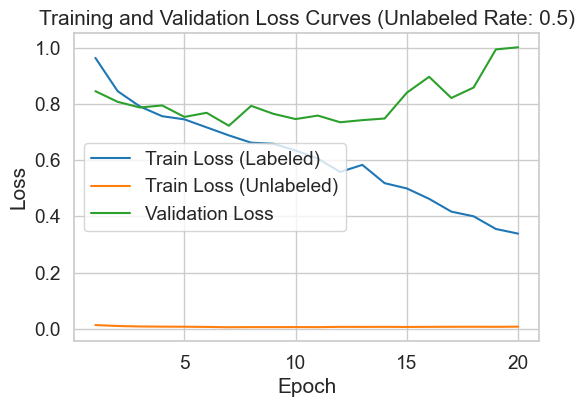

In [28]:
plot_loss_curves(ssl_history_50, use_unlabeled=True, unlabeled_rate=unlabeled_rate)

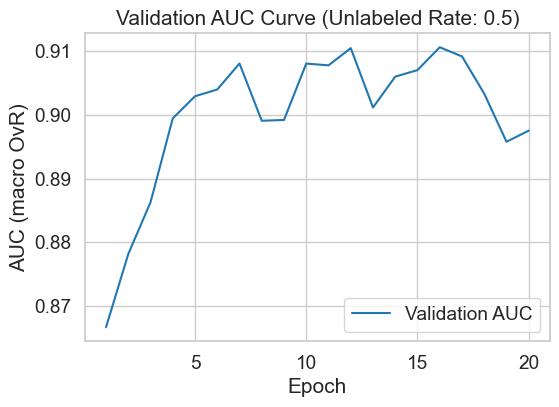

In [29]:
plot_auc_curve(ssl_history_50, unlabeled_rate=unlabeled_rate)

In [64]:
best_ssl_history_50 = max(ssl_history_50, key=lambda x: x['val_auc_macro'])
print(f"Best Epoch: {best_ssl_history_50['epoch']} | Val AUC Macro: {best_ssl_history_50['val_auc_macro']:.4f}")

best_ssl_model_50 = CNN(n_channels, n_classes)
best_ssl_model_50.load_state_dict(best_ssl_history_50['model_state'])

Best Epoch: 16 | Val AUC Macro: 0.9106


<All keys matched successfully>

In [65]:
test_auc_macro, test_auc_global = evaluate(best_ssl_model_50, test_loader)
print(f"Test AUC Macro: {test_auc_macro:.4f} | Test AUC Global: {test_auc_global:.4f}")

Test AUC Macro: 0.8936 | Test AUC Global: 0.9508


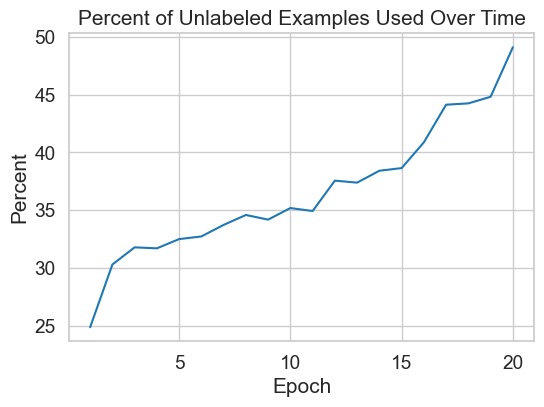

In [66]:
plot_percent_unlabeled_used(ssl_history_50)

In [67]:
with torch.no_grad():
    best_ssl_model_50.eval()
    probs, targets = [], []
    for images, labels in tqdm(test_loader):
        images = images.to('cpu')
        # mean_probs = best_ssl_model_50.average_probs(images, num_samples=10)
        # probs.append(mean_probs.cpu().numpy())
        outputs = best_ssl_model_50(images)
        probs.append(torch.softmax(outputs, dim=1).cpu().numpy())
        targets.append(labels.squeeze().cpu().numpy())

probs = np.concatenate(probs)
targets = np.concatenate(targets)
preds = np.argmax(probs, axis=1)
print(f"Percentage of predictions that are class 5: {(preds == 5).mean() * 100:.1f}%")

100%|██████████| 8/8 [00:00<00:00, 23.43it/s]

Percentage of predictions that are class 5: 79.7%


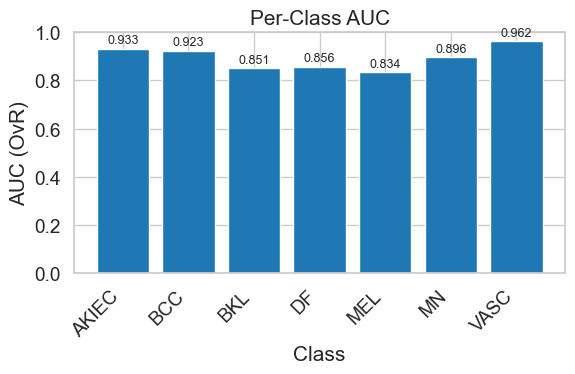

In [68]:
perclass_auc, confusion_matrix = evaluate_perclass(best_ssl_model_50, test_loader)
plot_perclass_auc(perclass_auc, list(short_labels.values()))

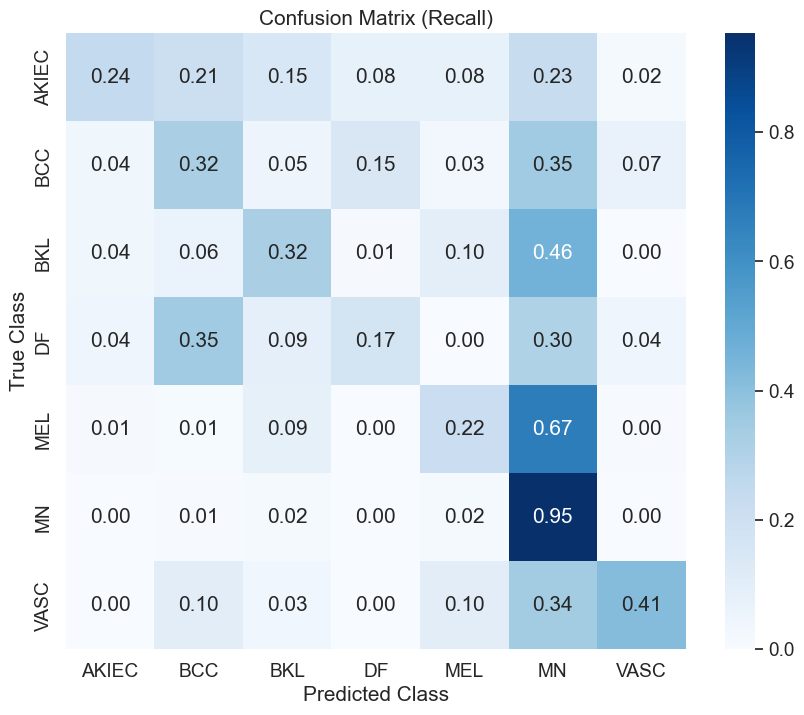

In [69]:
plot_per_class_recall(confusion_matrix, list(short_labels.values()))

In [37]:
confusion_matrix

array([[0.24242424, 0.21212121, 0.15151515, 0.07575758, 0.07575758,
        0.22727273, 0.01515152],
       [0.03883495, 0.32038835, 0.04854369, 0.14563107, 0.02912621,
        0.34951456, 0.06796117],
       [0.04090909, 0.06363636, 0.32272727, 0.01363636, 0.1       ,
        0.45909091, 0.        ],
       [0.04347826, 0.34782609, 0.08695652, 0.17391304, 0.        ,
        0.30434783, 0.04347826],
       [0.01345291, 0.00896861, 0.08520179, 0.        , 0.21524664,
        0.67264574, 0.0044843 ],
       [0.00298285, 0.00671141, 0.01789709, 0.        , 0.01715138,
        0.95302013, 0.00223714],
       [0.        , 0.10344828, 0.03448276, 0.        , 0.10344828,
        0.34482759, 0.4137931 ]])

### Trying 75% unlabeled rate

In [38]:
# Create SSL versions of our datasets
unlabeled_rate = 0.75

train_labels_ssl_75 = get_semi_supervised_labels(train_dataset, unlabeled_rate=unlabeled_rate, seed=RANDOM_SEED)
train_ssl_dataset_75 = SSLDataset(train_dataset, train_labels_ssl_75)
train_ssl_loader_75 = data.DataLoader(train_ssl_dataset_75, batch_size=BATCH_SIZE, shuffle=True)

Unlabeled rate: 0.75 | Total examples: 7007 | Labeled examples: 1754 | Unlabeled examples: 5253
Class 0: 57/228 labeled, 171 unlabeled
Class 1: 90/359 labeled, 269 unlabeled
Class 2: 193/769 labeled, 576 unlabeled
Class 3: 20/80 labeled, 60 unlabeled
Class 4: 195/779 labeled, 584 unlabeled
Class 5: 1174/4693 labeled, 3519 unlabeled
Class 6: 25/99 labeled, 74 unlabeled


In [39]:
ssl_model_75, criterion, optimizer = default_setup()
ssl_history_75 = train_loop_hard_pseudo_label(ssl_model_75, train_ssl_loader_75, val_loader, criterion, optimizer, num_epochs=20)

100%|██████████| 55/55 [00:04<00:00, 13.05it/s]


Epoch 1/20 | Train Loss Labeled: 1.0173 | Train Loss Unlabeled: 0.0151 | Val Loss: 0.8726 | Val AUC Macro: 0.8463 | Val AUC Global: 0.9356


100%|██████████| 55/55 [00:04<00:00, 12.23it/s]


Epoch 2/20 | Train Loss Labeled: 0.8798 | Train Loss Unlabeled: 0.0118 | Val Loss: 0.8288 | Val AUC Macro: 0.8677 | Val AUC Global: 0.9421


100%|██████████| 55/55 [00:04<00:00, 12.16it/s]


...

Epoch 18/20 | Train Loss Labeled: 0.3733 | Train Loss Unlabeled: 0.0071 | Val Loss: 1.0093 | Val AUC Macro: 0.8802 | Val AUC Global: 0.9479


100%|██████████| 55/55 [00:04<00:00, 12.00it/s]


Epoch 19/20 | Train Loss Labeled: 0.3644 | Train Loss Unlabeled: 0.0073 | Val Loss: 0.9849 | Val AUC Macro: 0.8795 | Val AUC Global: 0.9401


100%|██████████| 55/55 [00:04<00:00, 11.96it/s]


Epoch 20/20 | Train Loss Labeled: 0.3368 | Train Loss Unlabeled: 0.0079 | Val Loss: 1.0715 | Val AUC Macro: 0.8792 | Val AUC Global: 0.9411


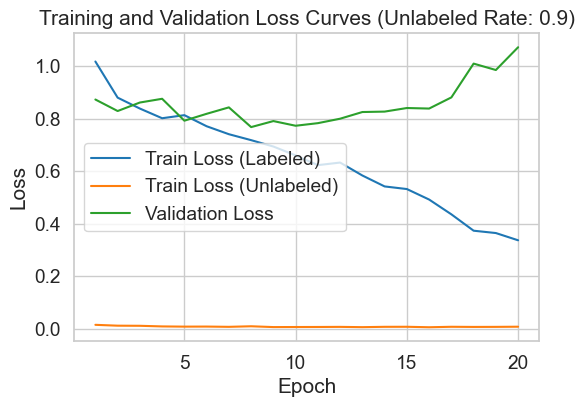

In [70]:
plot_loss_curves(ssl_history_75, use_unlabeled=True, unlabeled_rate=unlabeled_rate)

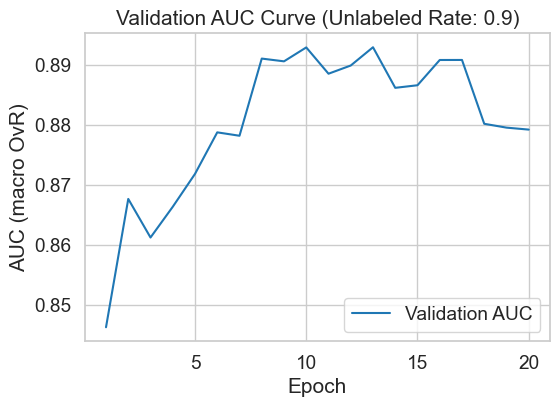

In [71]:
plot_auc_curve(ssl_history_75, unlabeled_rate=unlabeled_rate)

In [72]:
best_ssl_history_75 = max(ssl_history_75, key=lambda x: x['val_auc_macro'])
print(f"Best Epoch: {best_ssl_history_75['epoch']} | Val AUC Macro: {best_ssl_history_75['val_auc_macro']:.4f}")

best_ssl_model_75 = CNN(n_channels, n_classes)
best_ssl_model_75.load_state_dict(best_ssl_history_75['model_state'])

Best Epoch: 13 | Val AUC Macro: 0.8929


<All keys matched successfully>

In [73]:
test_auc_macro, test_auc_global = evaluate(best_ssl_model_75, test_loader)
print(f"Test AUC Macro: {test_auc_macro:.4f} | Test AUC Global: {test_auc_global:.4f}")

Test AUC Macro: 0.8723 | Test AUC Global: 0.9430


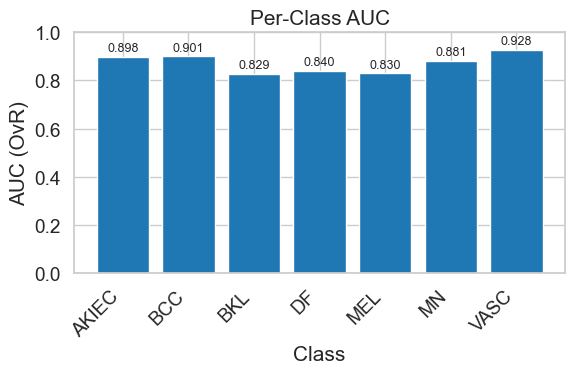

In [74]:
perclass_auc, confusion_matrix = evaluate_perclass(best_ssl_model_75, test_loader)
plot_perclass_auc(perclass_auc, list(short_labels.values()))

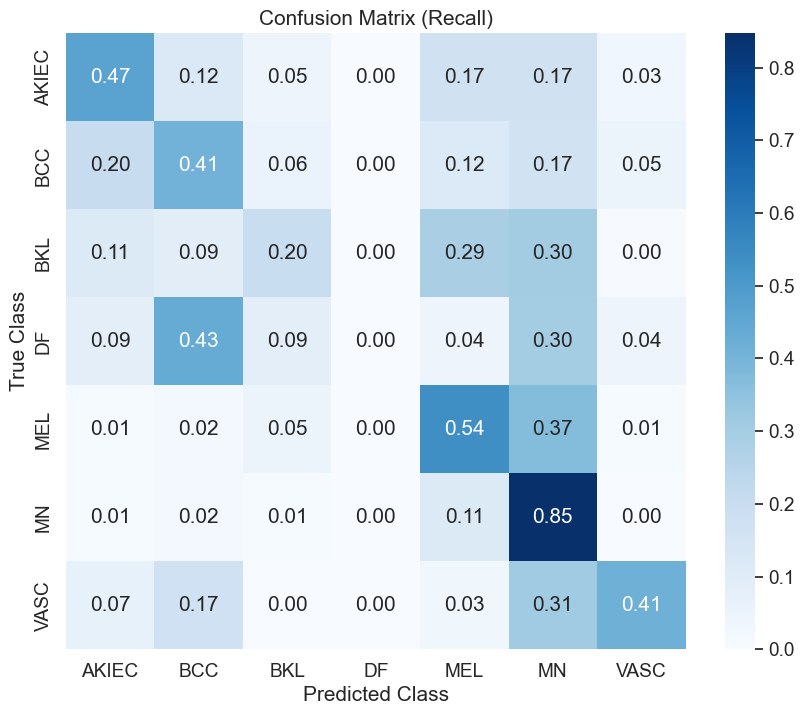

In [75]:
plot_per_class_recall(confusion_matrix, list(short_labels.values()))

In [76]:
with torch.no_grad():
    best_ssl_model_75.eval()
    probs, targets = [], []
    for images, labels in tqdm(test_loader):
        images = images.to('cpu')
        outputs = best_ssl_model_75(images)
        probs.append(torch.softmax(outputs, dim=1).cpu().numpy())
        targets.append(labels.squeeze().cpu().numpy())

probs = np.concatenate(probs)
targets = np.concatenate(targets)
preds = np.argmax(probs, axis=1)
print(f"Percentage of predictions that are class 5: {(preds == 5).mean() * 100:.1f}%")

100%|██████████| 8/8 [00:00<00:00, 24.92it/s]

Percentage of predictions that are class 5: 66.3%


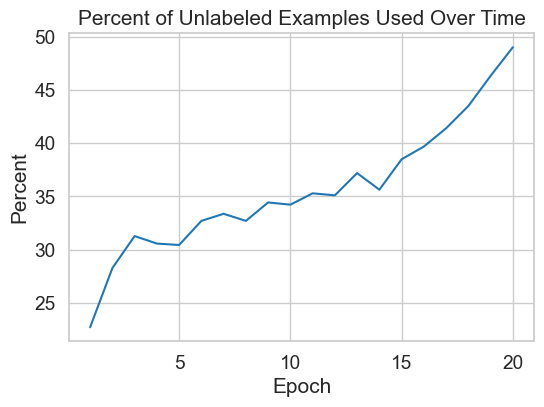

In [77]:
plot_percent_unlabeled_used(ssl_history_75)

### 90%

In [47]:
# Create SSL versions of our datasets
unlabeled_rate = 0.9

train_labels_ssl_90 = get_semi_supervised_labels(train_dataset, unlabeled_rate=unlabeled_rate, seed=RANDOM_SEED)
train_ssl_dataset_90 = SSLDataset(train_dataset, train_labels_ssl_90)
train_ssl_loader_90 = data.DataLoader(train_ssl_dataset_90, batch_size=BATCH_SIZE, shuffle=True)

Unlabeled rate: 0.9 | Total examples: 7007 | Labeled examples: 702 | Unlabeled examples: 6305
Class 0: 23/228 labeled, 205 unlabeled
Class 1: 36/359 labeled, 323 unlabeled
Class 2: 77/769 labeled, 692 unlabeled
Class 3: 8/80 labeled, 72 unlabeled
Class 4: 78/779 labeled, 701 unlabeled
Class 5: 470/4693 labeled, 4223 unlabeled
Class 6: 10/99 labeled, 89 unlabeled


In [48]:
ssl_model_90, criterion, optimizer = default_setup()
ssl_history_90 = train_loop_hard_pseudo_label(ssl_model_90, train_ssl_loader_90, val_loader, criterion, optimizer, num_epochs=20)

100%|██████████| 55/55 [00:04<00:00, 12.97it/s]


Epoch 1/20 | Train Loss Labeled: 1.1063 | Train Loss Unlabeled: 0.0153 | Val Loss: 0.9149 | Val AUC Macro: 0.8290 | Val AUC Global: 0.9313


100%|██████████| 55/55 [00:04<00:00, 12.66it/s]


Epoch 2/20 | Train Loss Labeled: 0.9471 | Train Loss Unlabeled: 0.0168 | Val Loss: 0.8839 | Val AUC Macro: 0.8298 | Val AUC Global: 0.9351


100%|██████████| 55/55 [00:04<00:00, 12.34it/s]


...

Epoch 18/20 | Train Loss Labeled: 0.5628 | Train Loss Unlabeled: 0.0113 | Val Loss: 1.0044 | Val AUC Macro: 0.8397 | Val AUC Global: 0.9320


100%|██████████| 55/55 [00:04<00:00, 12.40it/s]


Epoch 19/20 | Train Loss Labeled: 0.4963 | Train Loss Unlabeled: 0.0105 | Val Loss: 1.2503 | Val AUC Macro: 0.8256 | Val AUC Global: 0.9226


100%|██████████| 55/55 [00:04<00:00, 12.66it/s]


Epoch 20/20 | Train Loss Labeled: 0.4288 | Train Loss Unlabeled: 0.0118 | Val Loss: 1.3103 | Val AUC Macro: 0.8255 | Val AUC Global: 0.9209


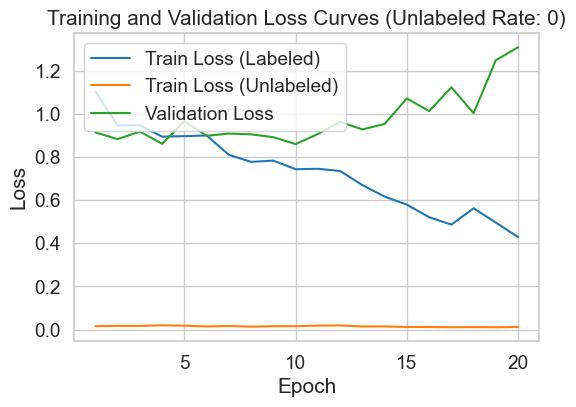

In [78]:
plot_loss_curves(ssl_history_90, use_unlabeled=True)

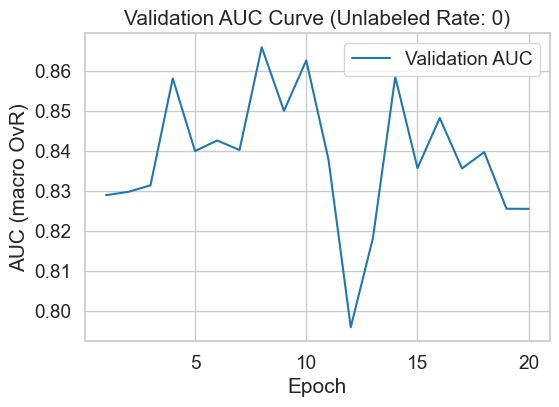

In [79]:
plot_auc_curve(ssl_history_90)

In [80]:
best_ssl_history_90 = max(ssl_history_90, key=lambda x: x['val_auc_macro'])
print(f"Best Epoch: {best_ssl_history_90['epoch']} | Val AUC Macro: {best_ssl_history_90['val_auc_macro']:.4f}")

best_ssl_model_90 = CNN(n_channels, n_classes)
best_ssl_model_90.load_state_dict(best_ssl_history_90['model_state'])

Best Epoch: 8 | Val AUC Macro: 0.8660


<All keys matched successfully>

In [81]:
test_auc_macro, test_auc_global = evaluate(best_ssl_model_90, test_loader)
print(f"Test AUC Macro: {test_auc_macro:.4f} | Test AUC Global: {test_auc_global:.4f}")

Test AUC Macro: 0.8343 | Test AUC Global: 0.9370


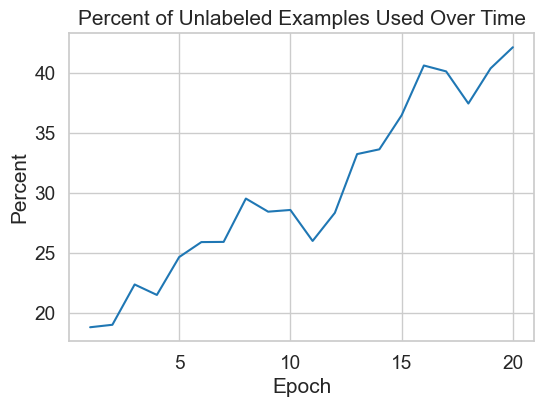

In [82]:
plot_percent_unlabeled_used(ssl_history_90)

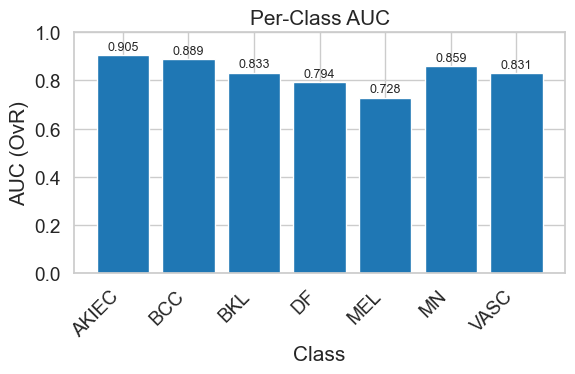

In [83]:
perclass_auc, confusion_matrix = evaluate_perclass(best_ssl_model_90, test_loader)
plot_perclass_auc(perclass_auc, list(short_labels.values()))

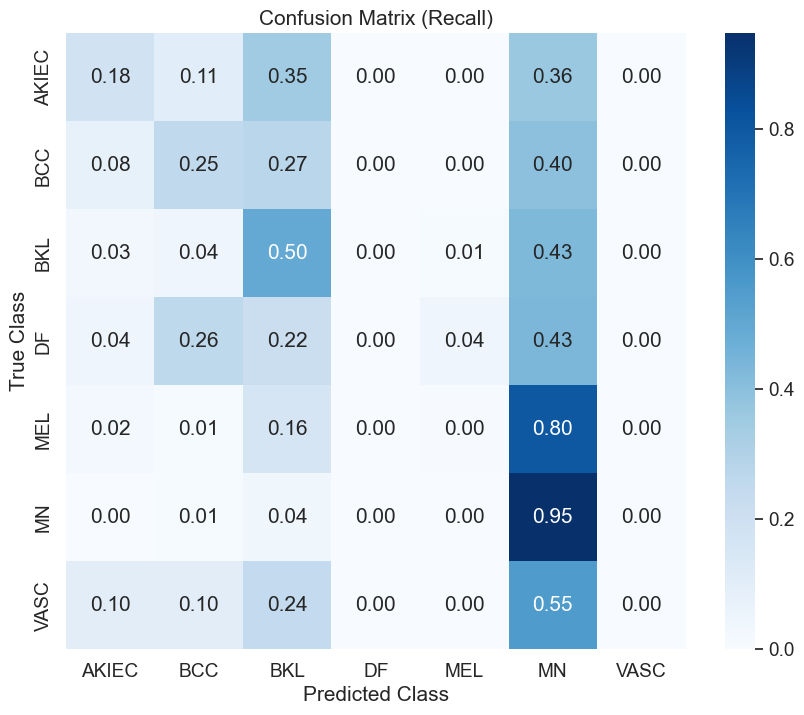

In [84]:
plot_per_class_recall(confusion_matrix, list(short_labels.values()))

In [85]:
with torch.no_grad():
    best_ssl_model_90.eval()
    probs, targets = [], []
    for images, labels in tqdm(test_loader):
        images = images.to('cpu')
        outputs = best_ssl_model_90(images)
        probs.append(torch.softmax(outputs, dim=1).cpu().numpy())
        targets.append(labels.squeeze().cpu().numpy())

probs = np.concatenate(probs)
targets = np.concatenate(targets)
preds = np.argmax(probs, axis=1)
print(f"Percentage of predictions that are class 5: {(preds == 5).mean() * 100:.1f}%")

100%|██████████| 8/8 [00:00<00:00, 25.24it/s]

Percentage of predictions that are class 5: 81.5%


## Hyperparameter Tuning
- We evaluate two hyperparameters via grid search: the learning rate, and the L2 penalty weight


### First at 50% unlabeled rate

In [62]:
# use the 50% unlabeled rate for hyperparam tuning
lr_values = [0.01, 0.001, 0.0001]
l2_pen_values = [0.0, 1e-4, 1e-3, 1e-2]

results_50 = []
for lr in lr_values:
    for l2_pen in l2_pen_values:
        print(f'Training with lr={lr} and l2_pen={l2_pen}')
        ssl_model_50_tuning, criterion, optimizer = default_setup(lr=lr, l2_weight=l2_pen)
        ssl_history_50_tuning = train_loop_hard_pseudo_label(ssl_model_50_tuning, train_ssl_loader_50, val_loader, criterion, optimizer, num_epochs=20)
        best_ssl_history_50_tuning = max(ssl_history_50_tuning, key=lambda x: x['val_auc_macro'])
        results_50.append({
            'lr': lr,
            'l2_pen': l2_pen,
            'output': best_ssl_history_50_tuning,
        })

Training with lr=0.01 and l2_pen=0.0


100%|██████████| 55/55 [00:04<00:00, 12.68it/s]


Epoch 1/20 | Train Loss Labeled: 1.1376 | Train Loss Unlabeled: 0.0181 | Val Loss: 1.0520 | Val AUC Macro: 0.7788 | Val AUC Global: 0.9191


100%|██████████| 55/55 [00:04<00:00, 12.58it/s]


Epoch 2/20 | Train Loss Labeled: 0.9650 | Train Loss Unlabeled: 0.0098 | Val Loss: 0.9154 | Val AUC Macro: 0.8240 | Val AUC Global: 0.9302


...

Epoch 18/20 | Train Loss Labeled: 0.3835 | Train Loss Unlabeled: 0.0091 | Val Loss: 0.7632 | Val AUC Macro: 0.9060 | Val AUC Global: 0.9541


100%|██████████| 55/55 [00:04<00:00, 11.47it/s]


Epoch 19/20 | Train Loss Labeled: 0.3603 | Train Loss Unlabeled: 0.0089 | Val Loss: 0.7751 | Val AUC Macro: 0.9059 | Val AUC Global: 0.9521


100%|██████████| 55/55 [00:04<00:00, 13.46it/s]


Epoch 20/20 | Train Loss Labeled: 0.3124 | Train Loss Unlabeled: 0.0092 | Val Loss: 0.7948 | Val AUC Macro: 0.9065 | Val AUC Global: 0.9518


In [63]:
best_hyperparam_combination_50 = max(results_50, key=lambda x: x['output']['val_auc_macro'])
sortedResults_50 = sorted(results_50, key=lambda x: x['output']['val_auc_macro'], reverse=True)
for result in sortedResults_50:
    print(f"lr: {result['lr']}, l2_pen: {result['l2_pen']}, val_auc_macro: {result['output']['val_auc_macro']:.4f}, val_auc_global: {result['output']['val_auc_global']:.4f}")

lr: 0.0001, l2_pen: 0.001, val_auc_macro: 0.9139, val_auc_global: 0.9567
lr: 0.001, l2_pen: 0.0001, val_auc_macro: 0.9135, val_auc_global: 0.9541
lr: 0.0001, l2_pen: 0.0001, val_auc_macro: 0.9128, val_auc_global: 0.9576
lr: 0.0001, l2_pen: 0.01, val_auc_macro: 0.9120, val_auc_global: 0.9566
lr: 0.001, l2_pen: 0.0, val_auc_macro: 0.9084, val_auc_global: 0.9566
lr: 0.001, l2_pen: 0.001, val_auc_macro: 0.9058, val_auc_global: 0.9566
lr: 0.0001, l2_pen: 0.0, val_auc_macro: 0.9038, val_auc_global: 0.9555
lr: 0.001, l2_pen: 0.01, val_auc_macro: 0.9002, val_auc_global: 0.9565
lr: 0.01, l2_pen: 0.0001, val_auc_macro: 0.8917, val_auc_global: 0.9478
lr: 0.01, l2_pen: 0.0, val_auc_macro: 0.8806, val_auc_global: 0.9445
lr: 0.01, l2_pen: 0.001, val_auc_macro: 0.8649, val_auc_global: 0.9424
lr: 0.01, l2_pen: 0.01, val_auc_macro: 0.8546, val_auc_global: 0.9395


### 75%

In [64]:
# use the 75% unlabeled rate for hyperparam tuning
lr_values = [0.01, 0.001, 0.0001]
l2_pen_values = [0.0, 1e-4, 1e-3, 1e-2]

results_75 = []
for lr in lr_values:
    for l2_pen in l2_pen_values:
        print(f'Training with lr={lr} and l2_pen={l2_pen}')
        ssl_model_75_tuning, criterion, optimizer = default_setup(lr=lr, l2_weight=l2_pen)
        ssl_history_75_tuning = train_loop_hard_pseudo_label(ssl_model_75_tuning, train_ssl_loader_75, val_loader, criterion, optimizer, num_epochs=20)
        best_ssl_history_75_tuning = max(ssl_history_75_tuning, key=lambda x: x['val_auc_macro'])
        results_75.append({
            'lr': lr,
            'l2_pen': l2_pen,
            'output': best_ssl_history_75_tuning,
        })

Training with lr=0.01 and l2_pen=0.0


  0%|          | 0/55 [00:00<?, ?it/s]

100%|██████████| 55/55 [00:04<00:00, 13.65it/s]


Epoch 1/20 | Train Loss Labeled: 1.1907 | Train Loss Unlabeled: 0.0139 | Val Loss: 1.0497 | Val AUC Macro: 0.7919 | Val AUC Global: 0.9192


100%|██████████| 55/55 [00:04<00:00, 13.43it/s]


...

Epoch 18/20 | Train Loss Labeled: 0.2594 | Train Loss Unlabeled: 0.0093 | Val Loss: 0.8497 | Val AUC Macro: 0.8975 | Val AUC Global: 0.9457


100%|██████████| 55/55 [00:04<00:00, 12.92it/s]


Epoch 19/20 | Train Loss Labeled: 0.2411 | Train Loss Unlabeled: 0.0084 | Val Loss: 0.8450 | Val AUC Macro: 0.8998 | Val AUC Global: 0.9477


100%|██████████| 55/55 [00:04<00:00, 12.93it/s]


Epoch 20/20 | Train Loss Labeled: 0.2148 | Train Loss Unlabeled: 0.0080 | Val Loss: 0.8667 | Val AUC Macro: 0.8991 | Val AUC Global: 0.9447


In [66]:
best_hyperparam_combination_75 = max(results_75, key=lambda x: x['output']['val_auc_macro'])
sortedResults_75 = sorted(results_75, key=lambda x: x['output']['val_auc_macro'], reverse=True)
for result in sortedResults_75:
    print(f"lr: {result['lr']}, l2_pen: {result['l2_pen']}, val_auc_macro: {result['output']['val_auc_macro']:.4f}, val_auc_global: {result['output']['val_auc_global']:.4f}")

lr: 0.0001, l2_pen: 0.01, val_auc_macro: 0.9086, val_auc_global: 0.9527
lr: 0.0001, l2_pen: 0.0001, val_auc_macro: 0.9067, val_auc_global: 0.9507
lr: 0.0001, l2_pen: 0.0, val_auc_macro: 0.9054, val_auc_global: 0.9493
lr: 0.001, l2_pen: 0.0, val_auc_macro: 0.9034, val_auc_global: 0.9528
lr: 0.0001, l2_pen: 0.001, val_auc_macro: 0.8970, val_auc_global: 0.9424
lr: 0.001, l2_pen: 0.001, val_auc_macro: 0.8953, val_auc_global: 0.9510
lr: 0.001, l2_pen: 0.0001, val_auc_macro: 0.8952, val_auc_global: 0.9472
lr: 0.001, l2_pen: 0.01, val_auc_macro: 0.8893, val_auc_global: 0.9477
lr: 0.01, l2_pen: 0.0, val_auc_macro: 0.8663, val_auc_global: 0.9413
lr: 0.01, l2_pen: 0.0001, val_auc_macro: 0.8572, val_auc_global: 0.9422
lr: 0.01, l2_pen: 0.001, val_auc_macro: 0.8510, val_auc_global: 0.9393
lr: 0.01, l2_pen: 0.01, val_auc_macro: 0.7907, val_auc_global: 0.9128


### Trying at 90%

In [69]:
# use the 90% unlabeled rate for hyperparam tuning
lr_values = [0.01, 0.001, 0.0001]
l2_pen_values = [0.0, 1e-4, 1e-3, 1e-2]

results_90 = []
for lr in lr_values:
    for l2_pen in l2_pen_values:
        print(f'Training with lr={lr} and l2_pen={l2_pen}')
        ssl_model_90_tuning, criterion, optimizer = default_setup(lr=lr, l2_weight=l2_pen)
        ssl_history_90_tuning = train_loop_hard_pseudo_label(ssl_model_90_tuning, train_ssl_loader_90, val_loader, criterion, optimizer, num_epochs=20)
        best_ssl_history_90_tuning = max(ssl_history_90_tuning, key=lambda x: x['val_auc_macro'])
        results_90.append({
            'lr': lr,
            'l2_pen': l2_pen,
            'output': best_ssl_history_90_tuning,
        })

Training with lr=0.01 and l2_pen=0.0


  0%|          | 0/55 [00:00<?, ?it/s]

100%|██████████| 55/55 [00:03<00:00, 14.09it/s]


Epoch 1/20 | Train Loss Labeled: 1.3217 | Train Loss Unlabeled: 0.0160 | Val Loss: 1.1434 | Val AUC Macro: 0.7499 | Val AUC Global: 0.9037


100%|██████████| 55/55 [00:03<00:00, 14.08it/s]


...

Epoch 18/20 | Train Loss Labeled: 0.2117 | Train Loss Unlabeled: 0.0103 | Val Loss: 1.0249 | Val AUC Macro: 0.8518 | Val AUC Global: 0.9272


100%|██████████| 55/55 [00:04<00:00, 13.26it/s]


Epoch 19/20 | Train Loss Labeled: 0.1837 | Train Loss Unlabeled: 0.0096 | Val Loss: 1.0314 | Val AUC Macro: 0.8435 | Val AUC Global: 0.9248


100%|██████████| 55/55 [00:04<00:00, 13.36it/s]


Epoch 20/20 | Train Loss Labeled: 0.1529 | Train Loss Unlabeled: 0.0082 | Val Loss: 1.0485 | Val AUC Macro: 0.8543 | Val AUC Global: 0.9259


In [71]:
best_hyperparam_combination_90 = max(results_90, key=lambda x: x['output']['val_auc_macro'])
sortedResults_90 = sorted(results_90, key=lambda x: x['output']['val_auc_macro'], reverse=True)
for result in sortedResults_90:
    print(f"lr: {result['lr']}, l2_pen: {result['l2_pen']}, val_auc_macro: {result['output']['val_auc_macro']:.4f}, val_auc_global: {result['output']['val_auc_global']:.4f}")

lr: 0.0001, l2_pen: 0.001, val_auc_macro: 0.8838, val_auc_global: 0.9437
lr: 0.0001, l2_pen: 0.01, val_auc_macro: 0.8747, val_auc_global: 0.9442
lr: 0.0001, l2_pen: 0.0001, val_auc_macro: 0.8657, val_auc_global: 0.9412
lr: 0.001, l2_pen: 0.001, val_auc_macro: 0.8626, val_auc_global: 0.9411
lr: 0.0001, l2_pen: 0.0, val_auc_macro: 0.8618, val_auc_global: 0.9393
lr: 0.001, l2_pen: 0.01, val_auc_macro: 0.8606, val_auc_global: 0.9411
lr: 0.001, l2_pen: 0.0001, val_auc_macro: 0.8531, val_auc_global: 0.9350
lr: 0.001, l2_pen: 0.0, val_auc_macro: 0.8488, val_auc_global: 0.9376
lr: 0.01, l2_pen: 0.0001, val_auc_macro: 0.8391, val_auc_global: 0.9357
lr: 0.01, l2_pen: 0.0, val_auc_macro: 0.8140, val_auc_global: 0.9311
lr: 0.01, l2_pen: 0.001, val_auc_macro: 0.7907, val_auc_global: 0.9241
lr: 0.01, l2_pen: 0.01, val_auc_macro: 0.7863, val_auc_global: 0.9159


## Test: Does burn-in using only labeled data help?

In [29]:
# First try without burn-in
ssl_model_75_nb, criterion, optimizer = default_setup(lr=0.0001, l2_weight=0.0)
ssl_history_75_nb = train_loop_hard_pseudo_label(ssl_model_75_nb, train_ssl_loader_75, val_loader, criterion, optimizer, num_epochs=20)

100%|██████████| 55/55 [00:03<00:00, 16.67it/s]


Epoch 1/20 | Train Loss Labeled: 1.2252 | Train Loss Unlabeled: 0.0271 | Val Loss: 0.9744 | Val Acc: 0.6690 | Val AUC: 0.7821


100%|██████████| 55/55 [00:04<00:00, 12.73it/s]


Epoch 2/20 | Train Loss Labeled: 0.9286 | Train Loss Unlabeled: 0.0198 | Val Loss: 0.8773 | Val Acc: 0.6690 | Val AUC: 0.8591


100%|██████████| 55/55 [00:04<00:00, 12.24it/s]


...

Epoch 18/20 | Train Loss Labeled: 0.2086 | Train Loss Unlabeled: 0.0090 | Val Loss: 0.8990 | Val Acc: 0.6909 | Val AUC: 0.8934


100%|██████████| 55/55 [00:04<00:00, 12.58it/s]


Epoch 19/20 | Train Loss Labeled: 0.1724 | Train Loss Unlabeled: 0.0078 | Val Loss: 0.9159 | Val Acc: 0.7388 | Val AUC: 0.8889


100%|██████████| 55/55 [00:04<00:00, 12.53it/s]


Epoch 20/20 | Train Loss Labeled: 0.1616 | Train Loss Unlabeled: 0.0078 | Val Loss: 0.9906 | Val Acc: 0.7328 | Val AUC: 0.8824


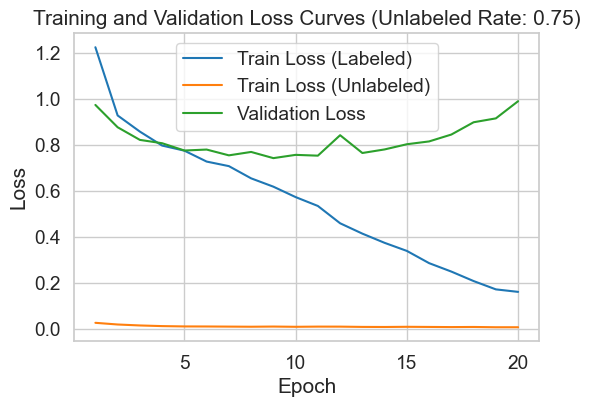

In [30]:
plot_loss_curves(ssl_history_75_nb, use_unlabeled=True, unlabeled_rate=0.75)

In [31]:
best_ssl_history_75_nb = max(ssl_history_75_nb, key=lambda x: x['val_auc'])
print(f"Best Epoch: {best_ssl_history_75_nb['epoch']} | Val AUC: {best_ssl_history_75_nb['val_auc']:.4f} | Val Acc: {best_ssl_history_75_nb['val_acc']:.4f}")

best_ssl_model_75_nb = CNN(n_channels, n_classes)
best_ssl_model_75_nb.load_state_dict(best_ssl_history_75_nb['model_state'])
test_auc = evaluate(best_ssl_model_75_nb, test_loader)
print(f"Test AUC: {test_auc:.4f}")

Best Epoch: 9 | Val AUC: 0.8997 | Val Acc: 0.7368
Test AUC: 0.8893


In [44]:
# then try with a small burn-in period of 3 epochs
num_burnin_epochs, total_epochs = 5, 20
ssl_model_75_burnin, criterion, optimizer = default_setup(lr=0.0001, l2_weight=0.0)
print(f'Starting burn-in training...')
burnin_history = train_loop_labeled(ssl_model_75_burnin, train_ssl_loader_75, val_loader, criterion, optimizer, num_epochs=num_burnin_epochs)
print(f'Burn-in training completed. Starting SSL training...')
ssl_history_75_post_burnin = train_loop_hard_pseudo_label(ssl_model_75_burnin, train_ssl_loader_75, val_loader, criterion, optimizer, num_epochs=total_epochs - num_burnin_epochs)

Starting burn-in training...


100%|██████████| 55/55 [00:01<00:00, 37.21it/s]


Epoch 1/5 | Train Loss: 1.2175 | Val Loss: 0.9688 | Val Acc: 0.6690 | Val AUC: 0.7800


100%|██████████| 55/55 [00:01<00:00, 38.05it/s]


Epoch 2/5 | Train Loss: 0.9223 | Val Loss: 0.8789 | Val Acc: 0.6750 | Val AUC: 0.8431


...

Epoch 13/15 | Train Loss Labeled: 0.2515 | Train Loss Unlabeled: 0.0084 | Val Loss: 0.8517 | Val Acc: 0.6929 | Val AUC: 0.8987


100%|██████████| 55/55 [00:04<00:00, 12.75it/s]


Epoch 14/15 | Train Loss Labeled: 0.2180 | Train Loss Unlabeled: 0.0084 | Val Loss: 0.8674 | Val Acc: 0.7198 | Val AUC: 0.8987


100%|██████████| 55/55 [00:04<00:00, 12.64it/s]


Epoch 15/15 | Train Loss Labeled: 0.1801 | Train Loss Unlabeled: 0.0076 | Val Loss: 0.8760 | Val Acc: 0.7238 | Val AUC: 0.8991


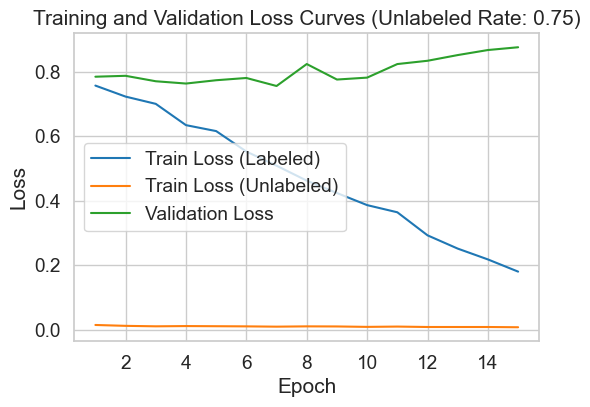

In [45]:
plot_loss_curves(ssl_history_75_post_burnin, use_unlabeled=True, unlabeled_rate=0.75)

In [46]:
best_ssl_history_75_burnin = max(ssl_history_75_post_burnin, key=lambda x: x['val_auc'])
print(f"Best Epoch: {best_ssl_history_75_burnin['epoch']} | Val AUC: {best_ssl_history_75_burnin['val_auc']:.4f} | Val Acc: {best_ssl_history_75_burnin['val_acc']:.4f}")

best_ssl_model_75_burnin = CNN(n_channels, n_classes)
best_ssl_model_75_burnin.load_state_dict(best_ssl_history_75_burnin['model_state'])
test_auc = evaluate(best_ssl_model_75_burnin, test_loader)
print(f"Test AUC: {test_auc:.4f}")

Best Epoch: 7 | Val AUC: 0.9071 | Val Acc: 0.7049
Test AUC: 0.8792
